# Experiment 1 & 2: Image Classification — Evaluation

Loads trained checkpoints for ResNet-18 (baseline) and ResNet-18 (customised) and evaluates
both models. Run after `A2_Classification_P1_Training.ipynb`.

**Student ID**: 26045171

In [1]:
import random
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchmetrics.classification import MulticlassAccuracy, MulticlassConfusionMatrix
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights, resnet18

In [2]:
STUDENT_ID = 26045171

torch.manual_seed(STUDENT_ID)
random.seed(STUDENT_ID)
np.random.seed(STUDENT_ID)
if torch.cuda.is_available():
    torch.cuda.manual_seed(STUDENT_ID)

DATASET_ROOT  = Path("26045171/Image_Classification/dataset")
EXP1_DIR      = Path("runs/exp1_resnet18")
EXP2_DIR      = Path("runs/exp2_resnet18_shallow")

NUM_CLASSES   = 10
BATCH_SIZE    = 256

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
base_dataset = ImageFolder(DATASET_ROOT)
CLASS_NAMES  = base_dataset.classes
print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")
print(f"Total images: {len(base_dataset)}")

indices = list(range(len(base_dataset)))
labels  = [label for _, label in base_dataset.imgs]

train_idx, temp_idx, _, temp_labels = train_test_split(
    indices, labels, test_size=0.30, stratify=labels, random_state=STUDENT_ID)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=STUDENT_ID)

all_by_class = defaultdict(list)
for idx, (_, lbl) in enumerate(base_dataset.imgs):
    all_by_class[lbl].append(idx)

tr_set, va_set = set(train_idx), set(val_idx)
print(f"\n{'Class':<22} {'Total':>5} {'Train':>5} {'Val':>4} {'Test':>4}")
print("-" * 44)
for lbl, name in enumerate(CLASS_NAMES):
    idxs = all_by_class[lbl]
    tr   = sum(1 for i in idxs if i in tr_set)
    va   = sum(1 for i in idxs if i in va_set)
    te   = len(idxs) - tr - va
    print(f"  {name:<20} {len(idxs):>5} {tr:>5} {va:>4} {te:>4}")
print("-" * 44)
print(f"  {'Total':<20} {len(base_dataset):>5} {len(train_idx):>5} {len(val_idx):>4} {len(test_idx):>4}")

Classes (10): ['Appenzeller', 'Lakeland_terrier', 'Leonberg', 'Samoyed', 'Weimaraner', 'Yorkshire_terrier', 'affenpinscher', 'briard', 'otterhound', 'schipperke']
Total images: 1707

Class                  Total Train  Val Test
--------------------------------------------
  Appenzeller            151   106   23   22
  Lakeland_terrier       197   138   29   30
  Leonberg               210   147   31   32
  Samoyed                218   152   33   33
  Weimaraner             160   112   24   24
  Yorkshire_terrier      164   115   24   25
  affenpinscher          150   105   23   22
  briard                 152   106   23   23
  otterhound             151   105   23   23
  schipperke             154   108   23   23
--------------------------------------------
  Total                 1707  1194  256  257


In [4]:
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class TransformDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label
    def __len__(self):
        return len(self.subset)

train_ds = TransformDataset(Subset(base_dataset, train_idx), val_transform)
val_ds   = TransformDataset(Subset(base_dataset, val_idx),   val_transform)
test_ds  = TransformDataset(Subset(base_dataset, test_idx),  val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 1194 | Val: 256 | Test: 257


In [5]:
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(model, loader, batch_size):
    model.eval()
    running_loss = 0.0
    total_images = 0
    metric = MulticlassAccuracy(num_classes=NUM_CLASSES).to(DEVICE)
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        running_loss += loss.item() * batch_size
        total_images += batch_size
        metric.update(outputs, labels)
    return running_loss / total_images, metric.compute().item()

In [6]:
class BasicBlock(nn.Module):
    """Two 3×3 conv layers with a residual skip connection (He et al., 2016)."""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        # 1×1 projection shortcut when spatial size or channel count changes
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)


def _make_layer(in_channels, out_channels, num_blocks, stride=1):
    layers = [BasicBlock(in_channels, out_channels, stride)]
    for _ in range(1, num_blocks):
        layers.append(BasicBlock(out_channels, out_channels))
    return nn.Sequential(*layers)


class ResNet18(nn.Module):
    """
    ResNet-18 (baseline).
    Stem: conv1(7×7, s2) → bn → relu → maxpool(3×3, s2)
    Body: layer1(64) → layer2(128) → layer3(256) → layer4(512)
    Head: AdaptiveAvgPool → fc
    Total convolutional layers: 17
    """
    def __init__(self, num_classes=1000):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.layer1  = _make_layer(64,  64,  2)
        self.layer2  = _make_layer(64,  128, 2, stride=2)
        self.layer3  = _make_layer(128, 256, 2, stride=2)
        self.layer4  = _make_layer(256, 512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer4(self.layer3(self.layer2(self.layer1(x))))
        return self.fc(torch.flatten(self.avgpool(x), 1))


class ResNet18Shallow(nn.Module):
    """
    ResNet-18 (customised) — layer4 removed.
    Stem: conv1(7×7, s2) → bn → relu → maxpool(3×3, s2)
    Body: layer1(64) → layer2(128) → layer3(256)   ← layer4 omitted
    Head: AdaptiveAvgPool → fc
    Total convolutional layers: 13 (vs 17 in baseline)
    Feature dimension entering classifier: 256 (vs 512 in baseline)
    """
    def __init__(self, num_classes=1000):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.layer1  = _make_layer(64,  64,  2)
        self.layer2  = _make_layer(64,  128, 2, stride=2)
        self.layer3  = _make_layer(128, 256, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer3(self.layer2(self.layer1(x)))
        return self.fc(torch.flatten(self.avgpool(x), 1))


## Load Trained Models

In [7]:
def build_resnet18(num_classes):
    model      = ResNet18(num_classes=num_classes)
    pretrained = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.conv1.load_state_dict(pretrained.conv1.state_dict())
    model.bn1.load_state_dict(pretrained.bn1.state_dict())
    model.layer1.load_state_dict(pretrained.layer1.state_dict())
    model.layer2.load_state_dict(pretrained.layer2.state_dict())
    model.layer3.load_state_dict(pretrained.layer3.state_dict())
    model.layer4.load_state_dict(pretrained.layer4.state_dict())
    return model

model1     = build_resnet18(NUM_CLASSES).to(DEVICE)
model1.load_state_dict(torch.load(EXP1_DIR / "best.pth", map_location=DEVICE, weights_only=True))
model1.eval()
total1     = sum(p.numel() for p in model1.parameters())
trainable1 = sum(p.numel() for p in model1.parameters() if p.requires_grad)
print(f"ResNet-18 (Baseline) loaded — {total1:,} params ({trainable1:,} trainable)")

ResNet-18 (Baseline) loaded — 11,181,642 params (11,181,642 trainable)


In [8]:
def build_resnet18_shallow(num_classes):
    model      = ResNet18Shallow(num_classes=num_classes)
    pretrained = resnet18(weights=ResNet18_Weights.DEFAULT)
    model.conv1.load_state_dict(pretrained.conv1.state_dict())
    model.bn1.load_state_dict(pretrained.bn1.state_dict())
    model.layer1.load_state_dict(pretrained.layer1.state_dict())
    model.layer2.load_state_dict(pretrained.layer2.state_dict())
    model.layer3.load_state_dict(pretrained.layer3.state_dict())
    return model

model2     = build_resnet18_shallow(NUM_CLASSES).to(DEVICE)
model2.load_state_dict(torch.load(EXP2_DIR / "best.pth", map_location=DEVICE, weights_only=True))
model2.eval()
total2     = sum(p.numel() for p in model2.parameters())
trainable2 = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f"ResNet-18 (Customised) loaded — {total2:,} params ({trainable2:,} trainable)")

ResNet-18 (Customised) loaded — 2,785,354 params (2,785,354 trainable)


## Evaluation

In [9]:
cm_metric1 = MulticlassConfusionMatrix(num_classes=NUM_CLASSES).to(DEVICE)
cm_metric2 = MulticlassConfusionMatrix(num_classes=NUM_CLASSES).to(DEVICE)

_, train_acc1 = evaluate(model1, train_loader, BATCH_SIZE)
_, val_acc1   = evaluate(model1, val_loader,   BATCH_SIZE)
_, test_acc1  = evaluate(model1, test_loader,  BATCH_SIZE)

_, train_acc2 = evaluate(model2, train_loader, BATCH_SIZE)
_, val_acc2   = evaluate(model2, val_loader,   BATCH_SIZE)
_, test_acc2  = evaluate(model2, test_loader,  BATCH_SIZE)

with torch.no_grad():
    for imgs, lbls in test_loader:
        cm_metric1.update(model1(imgs.to(DEVICE)), lbls.to(DEVICE))
        cm_metric2.update(model2(imgs.to(DEVICE)), lbls.to(DEVICE))

cm1 = cm_metric1.compute().cpu().numpy()
cm2 = cm_metric2.compute().cpu().numpy()

print("=== Exp 1 — ResNet-18 (Baseline) ===")
print(f"  Train: {train_acc1:.4f} | Val: {val_acc1:.4f} | Test: {test_acc1:.4f}")
print("\n=== Exp 2 — ResNet-18 (Customised) ===")
print(f"  Train: {train_acc2:.4f} | Val: {val_acc2:.4f} | Test: {test_acc2:.4f}")

=== Exp 1 — ResNet-18 (Baseline) ===
  Train: 1.0000 | Val: 0.9297 | Test: 0.9620

=== Exp 2 — ResNet-18 (Customised) ===
  Train: 0.9959 | Val: 0.8521 | Test: 0.8504


## Comparison — Exp 1 vs Exp 2

In [10]:
@torch.no_grad()
def get_preds(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        preds = model(images.to(DEVICE)).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

test_preds1, test_labels = get_preds(model1, test_loader)
test_preds2, _           = get_preds(model2, test_loader)

report1 = classification_report(test_labels, test_preds1, target_names=CLASS_NAMES, output_dict=True)
report2 = classification_report(test_labels, test_preds2, target_names=CLASS_NAMES, output_dict=True)

f1_1 = [report1[c]["f1-score"] for c in CLASS_NAMES]
f1_2 = [report2[c]["f1-score"] for c in CLASS_NAMES]

print("=== Exp 1 — ResNet-18 (Baseline) ===")
print(classification_report(test_labels, test_preds1, target_names=CLASS_NAMES))
print("=== Exp 2 — ResNet-18 Shallow (Customised) ===")
print(classification_report(test_labels, test_preds2, target_names=CLASS_NAMES))

=== Exp 1 — ResNet-18 (Baseline) ===
                   precision    recall  f1-score   support

      Appenzeller       1.00      0.95      0.98        22
 Lakeland_terrier       0.97      0.97      0.97        30
         Leonberg       0.97      1.00      0.98        32
          Samoyed       1.00      1.00      1.00        33
       Weimaraner       1.00      1.00      1.00        24
Yorkshire_terrier       1.00      0.96      0.98        25
    affenpinscher       0.88      1.00      0.94        22
           briard       0.92      0.96      0.94        23
       otterhound       0.95      0.83      0.88        23
       schipperke       0.96      0.96      0.96        23

         accuracy                           0.96       257
        macro avg       0.96      0.96      0.96       257
     weighted avg       0.97      0.96      0.96       257

=== Exp 2 — ResNet-18 Shallow (Customised) ===
                   precision    recall  f1-score   support

      Appenzeller       1.0

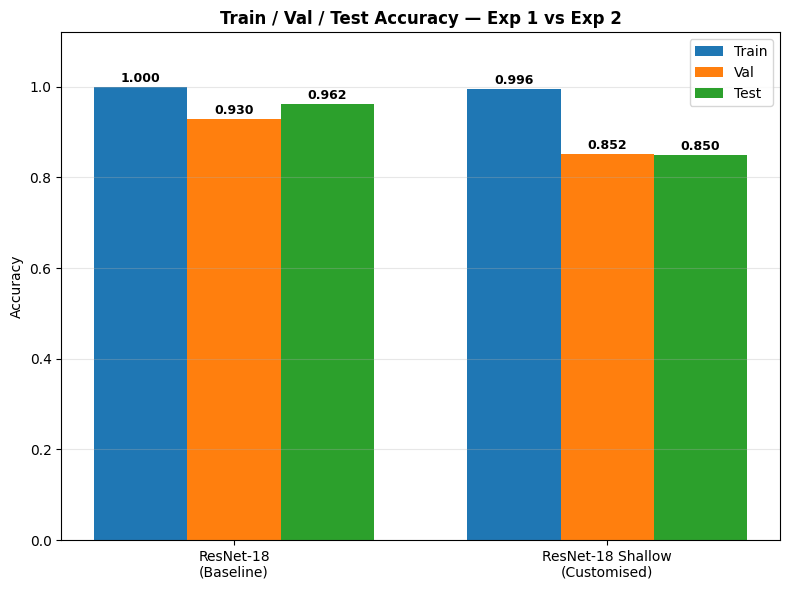


Parameter comparison:
  ResNet-18 (Exp 1):         11,181,642 params
  ResNet-18 Shallow (Exp 2):  2,785,354 params
  Reduction:                 75.1%


In [17]:
width = 0.25
x = np.arange(2)
train_accs = [train_acc1, train_acc2]
val_accs   = [val_acc1,   val_acc2]
test_accs  = [test_acc1,  test_acc2]

fig, ax = plt.subplots(figsize=(8, 6))
b_train = ax.bar(x - width, train_accs, width, label="Train", color="tab:blue")
b_val   = ax.bar(x,         val_accs,   width, label="Val",   color="tab:orange")
b_test  = ax.bar(x + width, test_accs,  width, label="Test",  color="tab:green")
ax.set_xticks(x)
ax.set_xticklabels(["ResNet-18\n(Baseline)", "ResNet-18 Shallow\n(Customised)"])
ax.set_ylabel("Accuracy")
ax.set_title("Train / Val / Test Accuracy — Exp 1 vs Exp 2", fontweight="bold")
ax.set_ylim(0, 1.12)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
for bars, vals in [(b_train, train_accs), (b_val, val_accs), (b_test, test_accs)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}",
                ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_comparison_accuracy.png", dpi=150)
plt.show()

print(f"\nParameter comparison:")
print(f"  ResNet-18 (Exp 1):         {total1:>10,} params")
print(f"  ResNet-18 Shallow (Exp 2): {total2:>10,} params")
print(f"  Reduction:                 {(1 - total2 / total1) * 100:.1f}%")

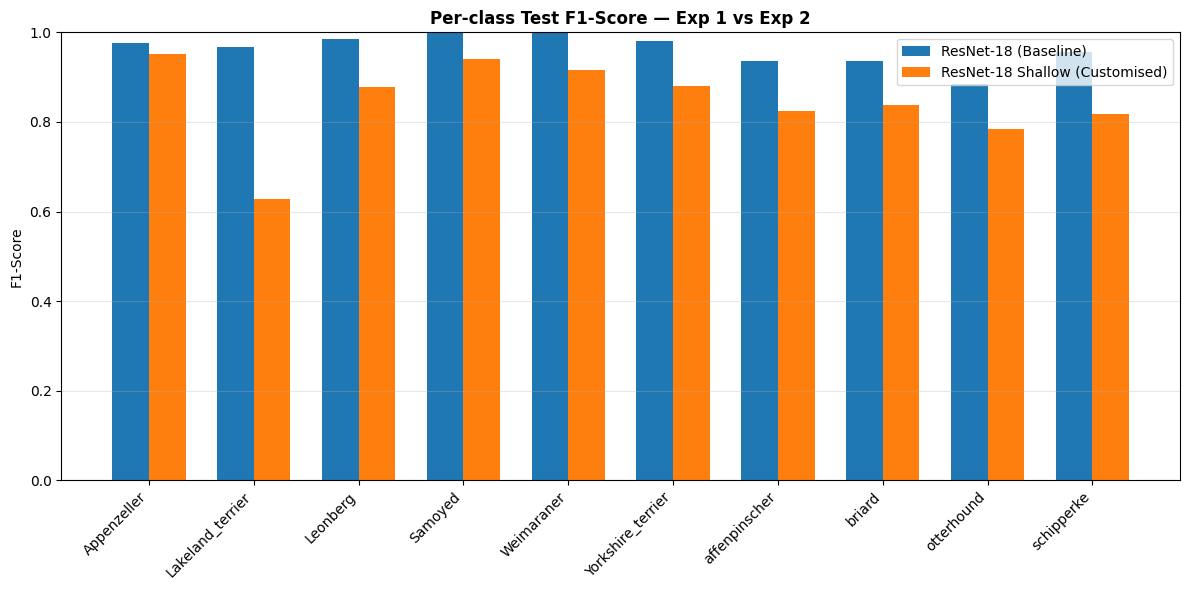

In [12]:
width = 0.35
xc = np.arange(NUM_CLASSES)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(xc - width / 2, f1_1, width, label="ResNet-18 (Baseline)",          color="tab:blue")
ax.bar(xc + width / 2, f1_2, width, label="ResNet-18 Shallow (Customised)", color="tab:orange")
ax.set_xticks(xc)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_ylabel("F1-Score")
ax.set_title("Per-class Test F1-Score — Exp 1 vs Exp 2", fontweight="bold")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("runs/cls_comparison_f1.png", dpi=150)
plt.show()

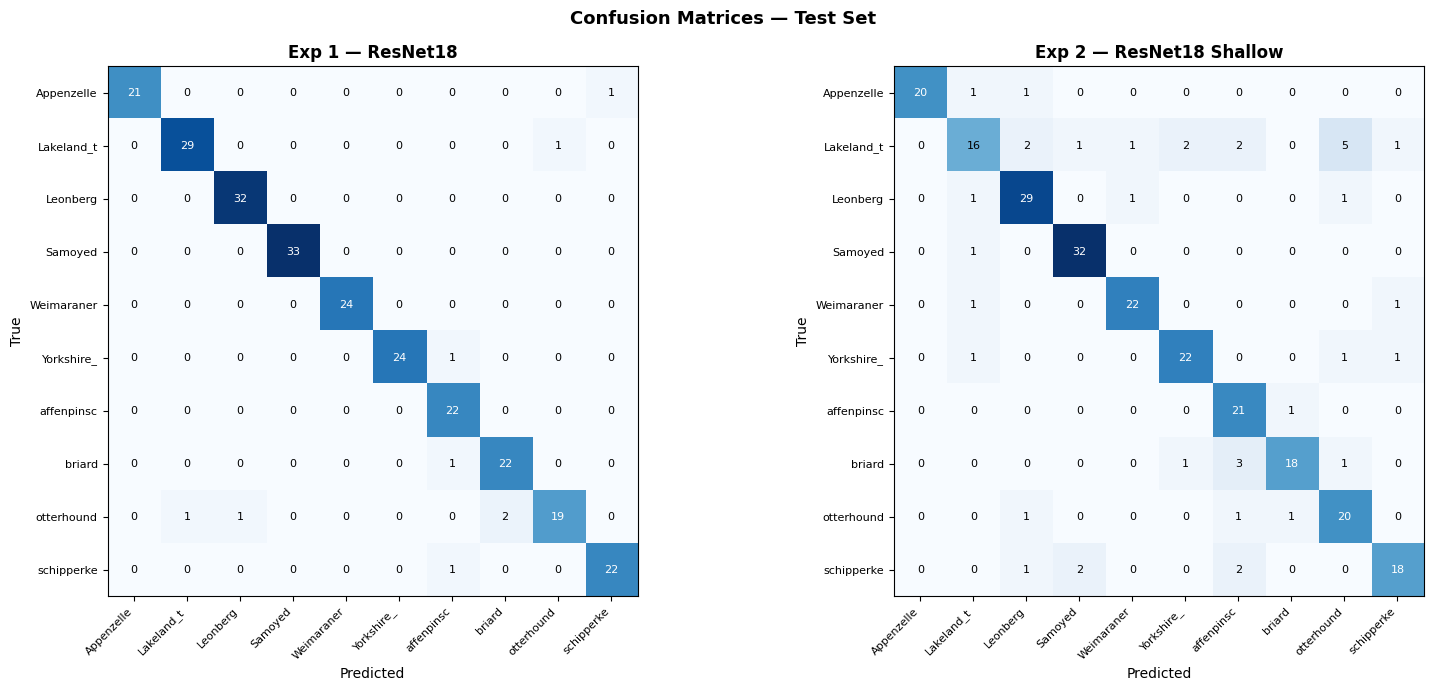

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
short_names = [c[:10] for c in CLASS_NAMES]
for ax, cm, title in [
    (ax1, cm1, "Exp 1 \u2014 ResNet18"),
    (ax2, cm2, "Exp 2 \u2014 ResNet18 Shallow")
]:
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    thresh = cm.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=8, color="white" if cm[i, j] > thresh else "black")
plt.suptitle("Confusion Matrices \u2014 Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("runs/cls_confusion_matrices.png", dpi=150)
plt.show()

### Exp 2 — Lakeland Terrier vs Otterhound: Grad-CAM Analysis

The customised model (Exp 2) misclassified several Lakeland Terriers as Otterhound.
Grad-CAM is run on both models across the same 9 images: 3 correctly classified Lakeland Terriers,
3 Lakeland Terriers that Exp 2 confused as Otterhound, and 3 Otterhound examples.
Each row shows the baseline (left) and customised model (right) side by side on the same image.
The target class for each image is the model's own predicted class — the heatmap shows what spatial
features drove that decision. Red borders mark incorrect predictions.

In [14]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denorm(img_t):
    return (img_t * std_t + mean_t).permute(1, 2, 0).clamp(0, 1).numpy()

LAKELAND_IDX   = CLASS_NAMES.index("Lakeland_terrier")
OTTERHOUND_IDX = CLASS_NAMES.index("otterhound")
N = 3

lakeland_correct  = []
lakeland_confused = []
otterhound_imgs   = []

with torch.no_grad():
    for i in range(len(test_ds)):
        if len(lakeland_correct) == N and len(lakeland_confused) == N and len(otterhound_imgs) == N:
            break
        img_t, true_label = test_ds[i]
        pred2 = model2(img_t.unsqueeze(0).to(DEVICE)).argmax(dim=1).item()
        if true_label == LAKELAND_IDX and pred2 == LAKELAND_IDX and len(lakeland_correct) < N:
            lakeland_correct.append(img_t)
        elif true_label == LAKELAND_IDX and pred2 == OTTERHOUND_IDX and len(lakeland_confused) < N:
            lakeland_confused.append(img_t)
        elif true_label == OTTERHOUND_IDX and len(otterhound_imgs) < N:
            otterhound_imgs.append(img_t)

print(f"Lakeland correct:      {len(lakeland_correct)}")
print(f"Lakeland → Otterhound: {len(lakeland_confused)}")
print(f"Otterhound:            {len(otterhound_imgs)}")

Lakeland correct:      3
Lakeland → Otterhound: 3
Otterhound:            3


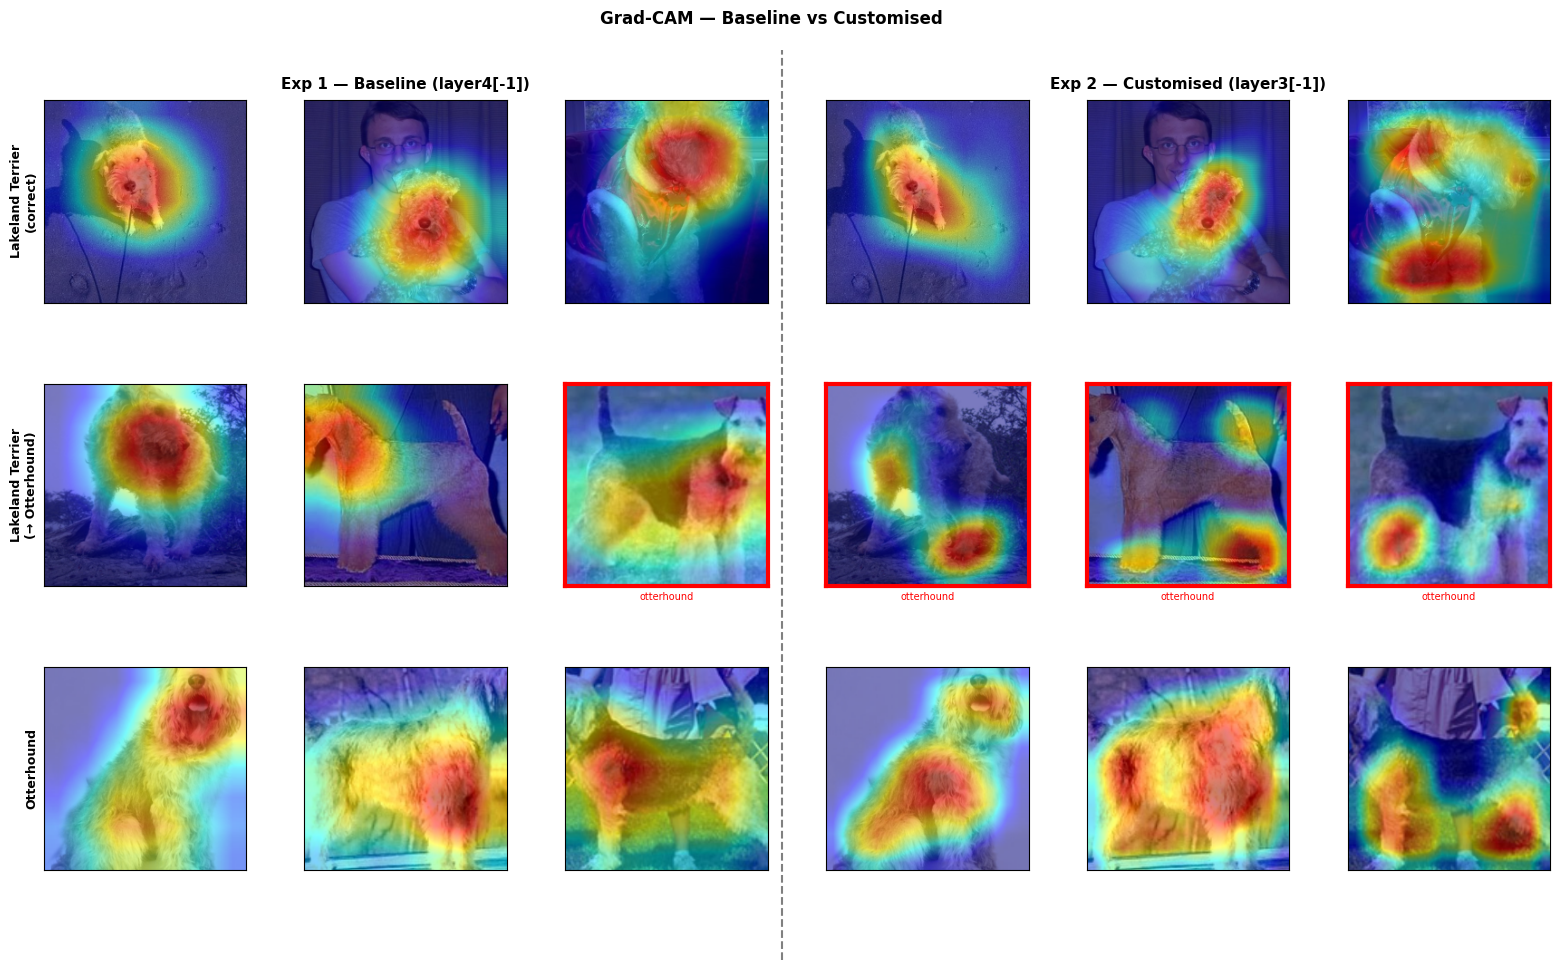

In [16]:
cam1 = GradCAM(model=model1, target_layers=[model1.layer4[-1]])
cam2 = GradCAM(model=model2, target_layers=[model2.layer3[-1]])

all_imgs           = [lakeland_correct, lakeland_confused, otterhound_imgs]
row_labels         = ["Lakeland Terrier\n(correct)", "Lakeland Terrier\n(→ Otterhound)", "Otterhound"]
true_labels_per_row = [LAKELAND_IDX, LAKELAND_IDX, OTTERHOUND_IDX]

fig, axes = plt.subplots(3, 6, figsize=(20, 10))
fig.subplots_adjust(wspace=0.06, hspace=0.4)

# vertical separator between baseline (cols 0-2) and customised (cols 3-5)
fig.add_artist(plt.Line2D(
    [0.505, 0.505], [0.02, 0.93], transform=fig.transFigure,
    color="gray", linewidth=1.5, linestyle="--"
))

for row_idx, (imgs, row_label, true_lbl) in enumerate(zip(all_imgs, row_labels, true_labels_per_row)):
    for col, img_t in enumerate(imgs):
        inp = img_t.unsqueeze(0).to(DEVICE)

        for model, cam, ax_col in [
            (model1, cam1, col),
            (model2, cam2, col + 3),
        ]:
            with torch.no_grad():
                pred = model(inp).argmax(dim=1).item()
            cam_map = cam(input_tensor=inp, targets=[ClassifierOutputTarget(pred)])[0]
            overlay = show_cam_on_image(denorm(img_t).astype(np.float32), cam_map, use_rgb=True)

            ax = axes[row_idx, ax_col]
            ax.imshow(overlay)
            ax.set_xticks([]); ax.set_yticks([])

            if pred != true_lbl:
                for spine in ax.spines.values():
                    spine.set_edgecolor("red")
                    spine.set_linewidth(3)
                ax.set_xlabel(f"✗ {CLASS_NAMES[pred]}", fontsize=7, color="red")

        if col == 0:
            axes[row_idx, 0].set_ylabel(row_label, fontsize=9, fontweight="bold")

axes[0, 1].set_title("Exp 1 — Baseline (layer4[-1])", fontsize=11, fontweight="bold", pad=8)
axes[0, 4].set_title("Exp 2 — Customised (layer3[-1])", fontsize=11, fontweight="bold", pad=8)

plt.suptitle(
    "Grad-CAM — Baseline vs Customised  |  ✗ red border = incorrect prediction",
    fontsize=12, fontweight="bold", y=0.97
)
plt.savefig("runs/cls_gradcam_comparison.png", dpi=150, bbox_inches="tight")
plt.show()